# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import find_combination, create_DS



import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

c0 ={'acc':'#941717', 'coriolis':'#388E3C','ggrad':'#42A5F5', 'wind':'#FFA000'}

_______
# Data

In [2]:
drifters_sources = 'all_med_variational_10min_v0.nc'
#DRIFTERS = {'all_med_variational_10min_v0' : os.path.join(zarr_dir, 'drifters_all_med_variational_10min_v0.csv')}
drifter_file = os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv'))
ALTI = {
    'swot250naive' : os.path.join(zarr_dir, 'swot_250_'+drifters_sources.replace('.nc', '')+'_naive.csv'), 
    'swot250gauss1e3' : os.path.join(zarr_dir, 'swot_250_'+drifters_sources.replace('.nc', '')+'_gauss1e3.csv'), 
}
WIND = {'era5' : os.path.join(zarr_dir, 'era5_'+drifters_sources.replace('.nc', '')+'.csv')}

In [3]:
def prepared_drifters() : 
    dfr = pd.read_csv(drifter_file).set_index('row_number')
    dfr['f'] =  2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr['coriolise']= -dfr.f * dfr.velocity_north
    dfr['coriolisn']= dfr.f * dfr.velocity_east
    dfr = dfr.rename(columns = {'acceleration_north':'accn', 'acceleration_east':'acce'})
    return dfr[['datetime', 'longitude', 'latitude', 'pass_number','time_to_swot','cycle_number','cycle_date','drifter_id','drifter_type','accn', 'acce', 'coriolise', 'coriolisn', 'velocity_east', 'velocity_north']]

def prepared_alti(alti_key, ggrad_var=['duacs_ssha_karin_2_filtered','cvl_mean_dynamic_topography_cnes_cls_22','cvl_ocean_tide_fes_2022']) :
    dfs = pd.read_csv(ALTI[alti_key]).set_index('row_number')
    dfs = dfs[['ggrade_'+v for v in ggrad_var]+['ggradn_'+v for v in ggrad_var]]
    dfs['ggrade_eta'] = dfs.ggrade_duacs_ssha_karin_2_filtered + dfs.ggrade_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggrade_cvl_ocean_tide_fes_2022
    dfs['ggradn_eta'] = dfs.ggradn_duacs_ssha_karin_2_filtered + dfs.ggradn_cvl_mean_dynamic_topography_cnes_cls_22+dfs.ggradn_cvl_ocean_tide_fes_2022
    return dfs.rename(columns ={v : v+'_' +alti_key for v in dfs})
    
def prepared_wind(wind_key): 
    dfw = pd.read_csv(WIND[wind_key]).set_index('row_number')
    dfw = dfw[[v for v in dfw if ('winde' in v or 'windn' in v)]+['inss', 'iews']]
    return dfw.rename(columns ={v : v+'_' +wind_key for v in dfw})

In [4]:
df = pd.concat([prepared_drifters(), prepared_alti('swot250naive'), prepared_alti('swot250gauss1e3'), prepared_wind('era5')], axis=1).dropna()

#depth
depth = df['pass_number'].copy()
depth.loc[df['drifter_type'].isin(surface_drifters)]=0
depth.loc[df['drifter_type'].isin(depth_drifters)]=15
depth.loc[df['drifter_id'].isin(depth_50)]=50
depth.loc[df['drifter_id'].isin(depth_100)]=100

df['depth'] = depth

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_14448/537934502.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfr = pd.read_csv(drifter_file).set_index('row_number')


In [5]:
# select only nearest in time colocalisation
def select_nearest_swot_coloc(df):
    idx = df.groupby(['pass_number','cycle_number','drifter_id']).time_to_swot.idxmin()
    return df.loc[idx]

dfc = select_nearest_swot_coloc(df).dropna()

In [6]:
dfc = dfc.reset_index().set_index('cycle_number')

dfc['meanflowe'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).velocity_east.mean().values)
dfc['meanflown'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).velocity_north.mean().values)
dfc['hfe'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).velocity_east.std().values)
dfc['hfn'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).velocity_north.std().values)
dfc['meanwinde'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).iews_era5.mean().values)
dfc['meanwindn'] = abs(df.groupby(['pass_number', 'cycle_number', 'drifter_id']).inss_era5.mean().values)

In [7]:
dfc = dfc.reset_index().set_index('row_number').dropna()

______
# Clustering

In [8]:
from sklearn.cluster import KMeans 

In [25]:
X = dfc[['meanflowe', 'hfe', 'meanwinde', 'meanflown', 'hfn', 'meanwindn']]
nc = 4

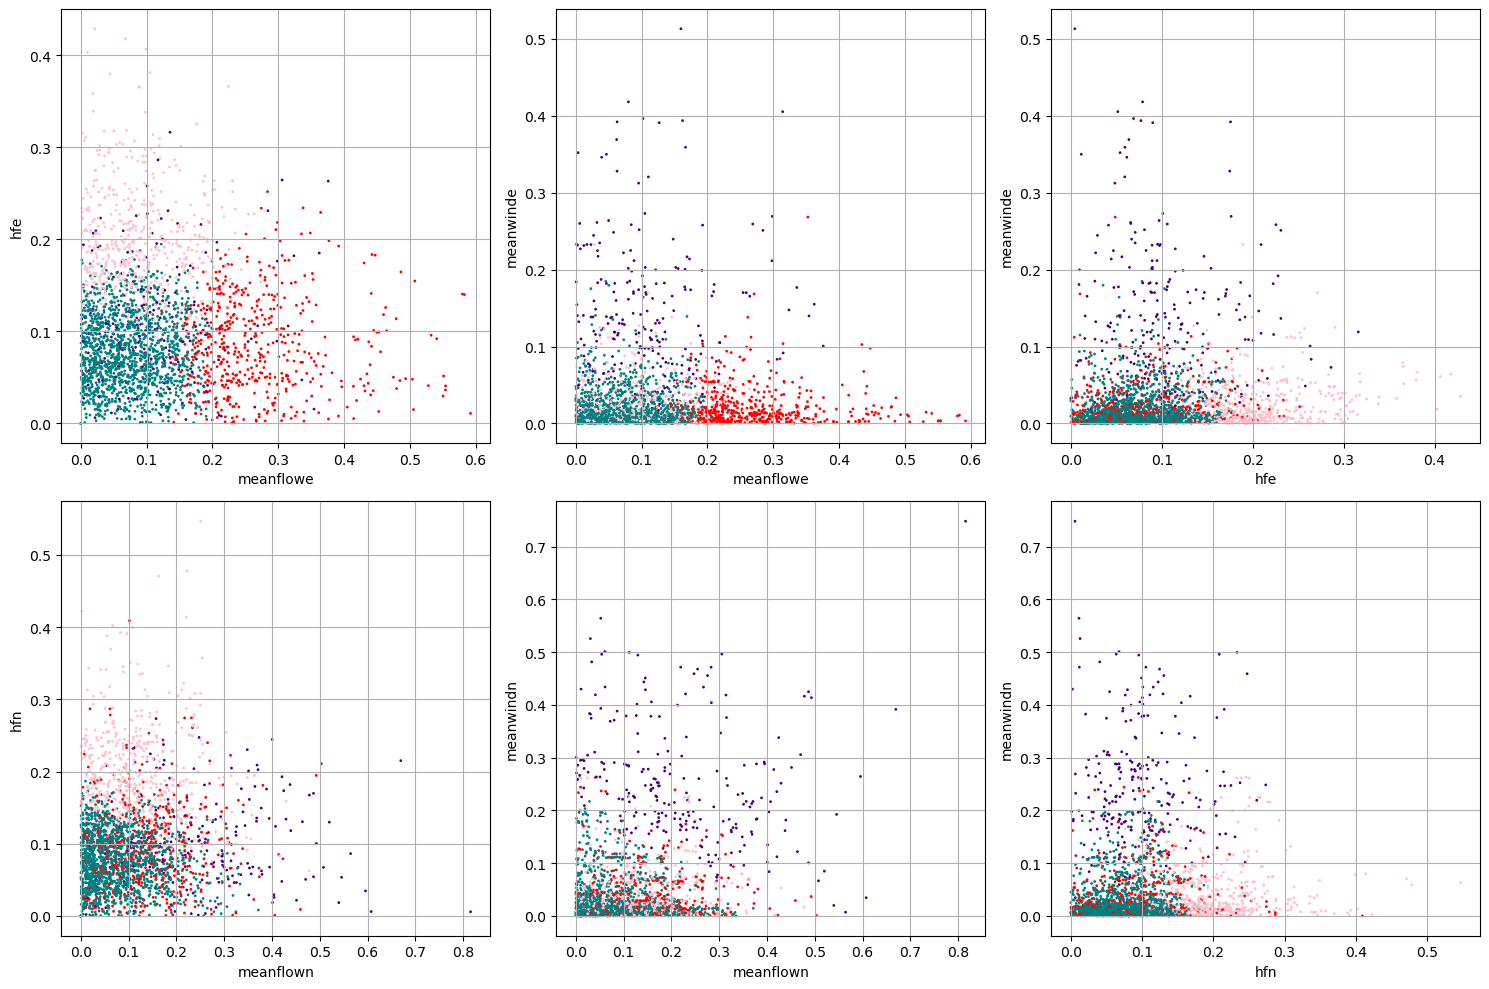

In [38]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
}
cmap='viridis'

fig, axs = plt.subplots(2,3, figsize=(15,10))
axs = axs.flatten()
s=1
y_pred = KMeans(n_clusters=nc, **common_params).fit_predict(X)

color = {0:'teal', 1:'indigo', 2:'red', 3:'pink', 4:'orange'}

c = np.where(y_pred==0, color[0], y_pred)
for i in range(1,nc) :
    c = np.where(y_pred==i, color[i], c)

dfc.plot.scatter('meanflowe', 'hfe', ax = axs[0], s=s, c=c)
dfc.plot.scatter('meanflowe', 'meanwinde', ax = axs[1], s=s, c=c)
dfc.plot.scatter('hfe', 'meanwinde', ax = axs[2], s=s, c=c)

dfc.plot.scatter('meanflown', 'hfn', ax = axs[3], s=s, c=c)
dfc.plot.scatter('meanflown', 'meanwindn', ax = axs[4], s=s, c=c)
dfc.plot.scatter('hfn', 'meanwindn', ax = axs[5], s=s, c=c)

for ax in axs:
    ax.grid()
    
fig.tight_layout()

Text(0.5, 0.92, 'Meridional')

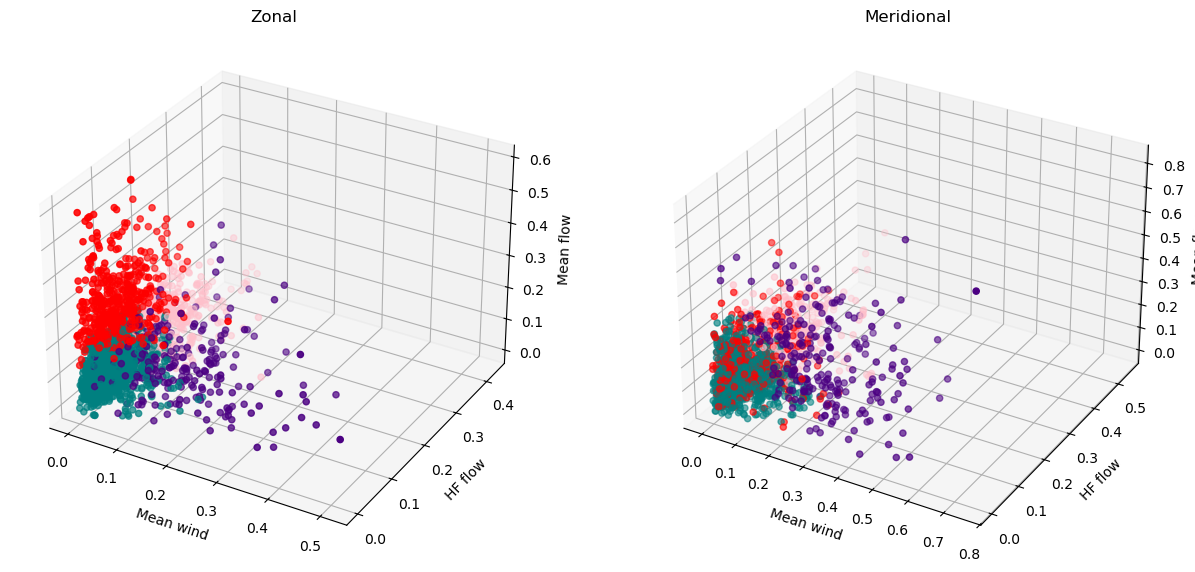

In [39]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(xs=dfc.meanwinde, ys =dfc.hfe, zs=dfc.meanflowe, c=c)
ax.set_title('Zonal')
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax = fig.add_subplot(122, projection='3d')
ax.scatter(xs=dfc.meanwindn, ys =dfc.hfn, zs=dfc.meanflown, c=c)
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax.set_title('Meridional')
#fig.tight_layout()

- 0-teal : low wind - low mean flow - low HF flow
- 1-indigo : high wind
- 2-red : low-wind - high zonal mean flow -low HF flow
- 3-pink : low wind - low mean flow - high HF flow 

In [40]:
color = {0:'teal', 1:'indigo', 2:'red', 3:'pink', 4:'orange'}

In [41]:
dfc['cluster'] = y_pred
df = df.reset_index().set_index(['pass_number','cycle_number','drifter_id'])
df['cluster']= dfc.reset_index().set_index(['pass_number','cycle_number','drifter_id'])['cluster']
df = df.reset_index().set_index('row_number')

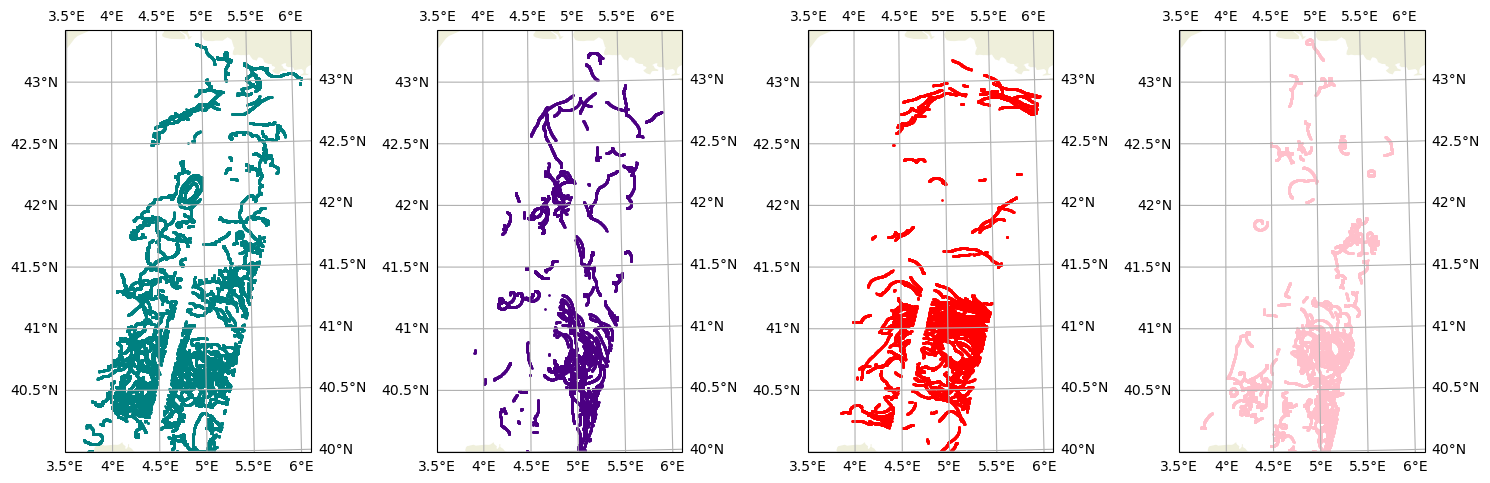

In [42]:
fig = plt.figure(figsize=(15,15))
#bbox =[2.7, 5.1, 36.6, 40]
#bbox = [0.9, 3.7, 37.7, 41.25]
bbox = [3.5, 6.1, 40, 43.4]
for i in range(nc) : 
    ax = fig.add_subplot(1,nc,i+1, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    df[df.cluster==i].plot.scatter(x='longitude', y='latitude',ax=ax, transform=crs, s=1, c=color[i])
    gl = ax.gridlines(draw_labels=True,)
    ax.add_feature(cfeature.LAND,)
    ax.set_extent(bbox)

fig.tight_layout()

_____
# STORE

In [43]:
df[['pass_number', 'cycle_number', 'drifter_id', 'cluster']].to_csv(os.path.join(zarr_dir, f'cluster_{nc}.csv'))

In [44]:
df

,pass_number,cycle_number,drifter_id,datetime,longitude,latitude,time_to_swot,cycle_date,drifter_type,accn,...,ggrade_eta_swot250gauss1e3,ggradn_eta_swot250gauss1e3,winde0_era5,windn0_era5,winde15_era5,windn15_era5,inss_era5,iews_era5,depth,cluster
row_number,,,,,,,,,,,,,,,,,,,,,
0,3,478,300534060315840,2023-04-01 11:50:00,4.811970,42.220893,0 days 11:52:32.696536,2023-04-01 23:42:32.696536000,SVP,-0.000012,...,0.000015,0.000010,-1.320922e-05,-0.000007,-3.642340e-06,-8.342680e-07,-0.162019,0.195854,15,1.0
1,3,478,300534060315840,2023-04-01 12:00:00,4.812432,42.221430,0 days 11:42:32.696536,2023-04-01 23:42:32.696536000,SVP,-0.000012,...,0.000016,0.000010,-1.277063e-05,-0.000007,-3.531180e-06,-8.430640e-07,-0.155654,0.191723,15,1.0
2,3,478,300534060315840,2023-04-01 12:10:00,4.812916,42.221930,0 days 11:32:32.696536,2023-04-01 23:42:32.696536000,SVP,-0.000011,...,0.000016,0.000010,-1.219325e-05,-0.000007,-3.377912e-06,-8.287643e-07,-0.147974,0.184603,15,1.0
3,3,478,300534060315840,2023-04-01 12:20:00,4.813418,42.222394,0 days 11:22:32.696536,2023-04-01 23:42:32.696536000,SVP,-0.000010,...,0.000016,0.000010,-1.161628e-05,-0.000006,-3.224727e-06,-8.143826e-07,-0.140301,0.177482,15,1.0
4,3,478,300534060315840,2023-04-01 12:30:00,4.813933,42.222825,0 days 11:12:32.696536,2023-04-01 23:42:32.696536000,SVP,-0.000009,...,0.000016,0.000010,-1.103974e-05,-0.000006,-3.071636e-06,-7.999297e-07,-0.132637,0.170361,15,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,16,577,300534060015760,2023-07-10 06:10:00,2.417785,39.788394,0 days 11:13:38.131544384,2023-07-09 18:56:21.868455616,SVP,0.000006,...,0.000030,-0.000028,-2.507479e-07,0.000004,1.699877e-07,8.766066e-07,-0.028485,-0.057068,15,0.0
383259,16,577,300534060015760,2023-07-10 06:20:00,2.416881,39.788885,0 days 11:23:38.131544384,2023-07-09 18:56:21.868455616,SVP,0.000007,...,0.000031,-0.000027,-2.203439e-07,0.000003,1.716770e-07,8.535433e-07,-0.027386,-0.055834,15,0.0
383260,16,577,300534060015760,2023-07-10 06:30:00,2.415948,39.789399,0 days 11:33:38.131544384,2023-07-09 18:56:21.868455616,SVP,0.000008,...,0.000031,-0.000026,-1.894054e-07,0.000003,1.734786e-07,8.303826e-07,-0.026277,-0.054599,15,0.0
